# Folding Time and Population Estimations

In [1]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import numpy as np
import pandas as pd

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.minor.width": 0.7,
    "ytick.minor.width": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.patches import Patch
from matplotlib import color_sequences
from matplotlib.colors import TwoSlopeNorm

#import networkx as nx # graph visualization of MSM microstates and macrostates model

from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM

---
## Prepare data for analysis


Reload data (after clustering)

In [2]:
trajectories_labels = ["tica_distances", "pca_distances", "tica_dihedrals", "pca_dihedrals"]


total_time_micros = 305
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames


# --------------------------------
# RMSD from crystal distances
# --------------------------------
crystal_dist = np.loadtxt(
    data_folder + "hp35.crystaldists",
    delimiter=" ",
    dtype=float
)

print("Crystal distances shape", crystal_dist.shape) 
rmsd = np.sqrt(np.mean(crystal_dist**2, axis=1))  # [nm]

Time step (microseconds) 0.00019986356854108112
Time step (nanoseconds) 0.19986356854108112
Time step (picoseconds) 199.86356854108112
One microsecond in frames 5003
Crystal distances shape (1526041, 53)


In [3]:
MSM_LAG_NS = 50
MSM_LAG_FRAMES = int(MSM_LAG_NS / time_step_nanos)
print("MSM lag time in frames:", MSM_LAG_FRAMES)
N_CLUSTERS = 50
tce = TransitionCountEstimator(lagtime=MSM_LAG_FRAMES, count_mode="sliding-effective")



msm_dict = {}
micro_trajectory_dict = {} # traj -> micro traj
dtrajs_dict = {} # traj -> micro traj



for i, name in enumerate(trajectories_labels):
    data = np.load(f"../intermediate_outputs/kmeans_plusplus/{N_CLUSTERS}clusters_{name}.npz")
    dtraj = data["traj"].copy()
    centers = data["centers"].copy()
    C = tce.fit(dtraj).fetch_model()
    submodel = C.submodel_largest(directed=True)
    print(f"Submodel for {name} has {submodel.n_states} microstates.")
    micro_trajectory_dict[name] = submodel.transform_discrete_trajectories_to_submodel(data["traj"])
    np.save(f"../intermediate_outputs/microstate_trajs/{N_CLUSTERS}clusters_{MSM_LAG_NS}lag_{name}_submodel.npy", micro_trajectory_dict[name])

    dtrajs_dict[name] = pu.clean_assignments(micro_trajectory_dict[name], max_dist= 10000)
    if np.any(dtrajs_dict[name] == -1):
        print(f"Warning: {name} has unassigned microstates after cleaning.")
    msm = MaximumLikelihoodMSM(reversible = True).fit(submodel).fetch_model()
    msm_dict[name] = msm

MSM lag time in frames: 250
Submodel for tica_distances has 50 microstates.
Submodel for pca_distances has 21 microstates.
Submodel for tica_dihedrals has 49 microstates.
Submodel for pca_dihedrals has 50 microstates.


Compute PCCA assignments

In [4]:
n_common = 2

pcca_dict = {}
pcca_memberships_dict = {}
macro_assignments_micro_dict = {}

for name in trajectories_labels:
    msm = msm_dict[name]

    pcca = msm.pcca(n_common)
    pcca_dict[name] = pcca

    # shape: n_microstates x 2
    memberships = pcca.memberships
    pcca_memberships_dict[name] = memberships

    # hard assignment of each microstate
    macro_assignments_micro = memberships.argmax(axis=1)
    macro_assignments_micro_dict[name] = macro_assignments_micro

In [5]:
pcca_probabilities_timeseries_dict = {}
hard_assignments_timeseries_dict = {}

for name in trajectories_labels:
    dtraj = dtrajs_dict[name]
    memberships = pcca_memberships_dict[name]


    # probability of belonging to macrostate 1
    p_macro1 = memberships[dtraj, 1]

    # hard macrostate assignment
    hard = np.argmax(memberships[dtraj, :], axis=1)


    pcca_probabilities_timeseries_dict[name] = p_macro1
    hard_assignments_timeseries_dict[name] = hard

#### Cored trajectory - compared pipelines

In [6]:
def core_two_state_trajectory(hard, min_core_frames):
    """
    Apply temporal coring to a discrete two-state trajectory.

    A transition from the current state to a new state is accepted only if
    the trajectory remains continuously in the new state for at least
    `min_core_frames`.

    Parameters
    ----------
    hard : array-like
        Discrete trajectory containing state labels 0 and 1.
    min_core_frames : int
        Minimum consecutive number of frames required to accept a new state.

    Returns
    -------
    cored : np.ndarray
        Cored trajectory with the same shape as `hard`.
    """
    hard = np.asarray(hard, dtype=int)

    if hard.ndim != 1:
        raise ValueError("hard must be a one-dimensional trajectory.")

    if len(hard) == 0:
        return hard.copy()

    if not np.all(np.isin(hard, [0, 1])):
        raise ValueError("hard must contain only state labels 0 and 1.")

    min_core_frames = max(1, int(min_core_frames))

    cored = np.empty_like(hard)

    current_state = hard[0]
    cored[:] = current_state

    candidate_state = None
    candidate_start = None
    candidate_length = 0

    for i in range(1, len(hard)):
        observed_state = hard[i]

        if observed_state == current_state:
            # Returned to the current core before completing a transition
            candidate_state = None
            candidate_start = None
            candidate_length = 0
            cored[i] = current_state
            continue

        if observed_state == candidate_state:
            candidate_length += 1
        else:
            # Start testing a different candidate state
            candidate_state = observed_state
            candidate_start = i
            candidate_length = 1

        if candidate_length >= min_core_frames:
            # Accept the transition retroactively from its first frame
            current_state = candidate_state
            cored[candidate_start:i + 1] = current_state

            candidate_state = None
            candidate_start = None
            candidate_length = 0
        else:
            # Candidate has not yet remained long enough
            cored[i] = current_state

    return cored


min_core_markov_steps = 1

min_core_mus = (
    min_core_markov_steps
    * MSM_LAG_NS
    / 1000
)

min_core_frames = max(
    1,
    int(np.ceil(min_core_mus / time_step_micros))
)

print("Minimum core time:", min_core_mus, "µs")
print("Minimum core frames:", min_core_frames)


cored_assignments_timeseries_dict = {}

for name in trajectories_labels:
    hard = hard_assignments_timeseries_dict[name]

    cored_assignments_timeseries_dict[name] = (
        core_two_state_trajectory(
            hard,
            min_core_frames=min_core_frames
        )
    )

Minimum core time: 0.05 µs
Minimum core frames: 251


Plot

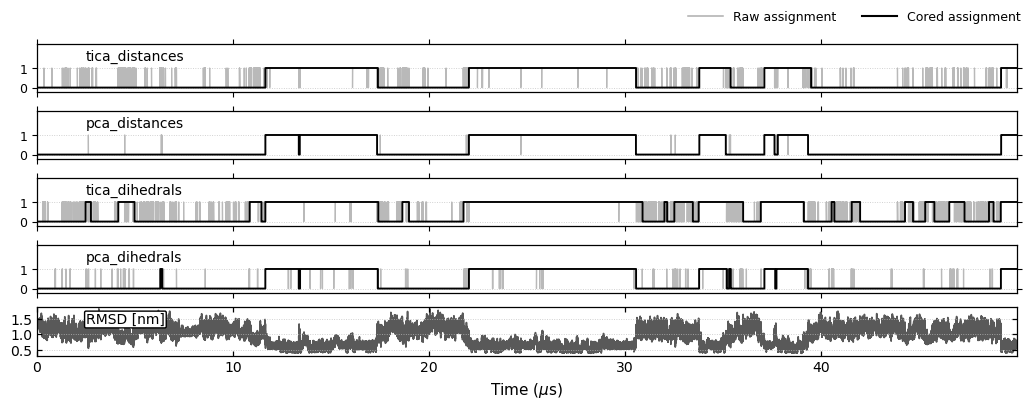

In [7]:
from matplotlib.lines import Line2D


# -----------------------------------------------------------
# Time window
# ------------------------------------------------------------
tmin_mus = 0
tmax_mus = 50

frame_min = max(
    0,
    int(np.floor(tmin_mus / time_step_micros))
)

frame_max = min(
    len(hard_assignments_timeseries_dict[trajectories_labels[0]]),
    int(np.ceil(tmax_mus / time_step_micros))
)

if frame_max <= frame_min:
    raise ValueError("The selected time window contains no trajectory frames.")

time_mus = (
    np.arange(frame_min, frame_max)
    * time_step_micros
)


# ------------------------------------------------------------
# Labels shown in the figure
# ------------------------------------------------------------



# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
n_models = len(trajectories_labels)

fig, axs = plt.subplots(
    nrows=n_models + 1,
    ncols=1,
    figsize=(10.2,  4.),
    sharex=True,
    sharey=False,
    constrained_layout=True
)

axs = np.atleast_1d(axs)

for panel_index, (ax, name) in enumerate(
    zip(axs, trajectories_labels)
):
    raw = np.asarray(
        hard_assignments_timeseries_dict[name][frame_min:frame_max]
    )
    cored = np.asarray(
        cored_assignments_timeseries_dict[name][frame_min:frame_max]
    )

    if len(raw) != len(time_mus) or len(cored) != len(time_mus):
        raise ValueError(
            f"Trajectory length mismatch for model '{name}'."
        )

    # Raw assignment: secondary information
    ax.step(
        time_mus,
        raw,
        where="post",
        color="0.68",
        linewidth=0.9,
        alpha=0.85,
        zorder=1
    )

    # Cored assignment: primary information
    ax.step(
        time_mus,
        cored,
        where="post",
        color="black",
        linewidth=1.35,
        zorder=2
    )



    # Panel label
    ax.text(
        +0.05,
        0.88,
        f"{name}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10
    )

    # State axis
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["0", "1"])
    ax.set_ylim(-0.25, 2.25)

    # Light horizontal guides
    ax.grid(
        axis="y",
        linestyle=":",
        linewidth=0.65,
        color="0.75",
        alpha=0.8,
        zorder=0
    )



    ax.tick_params(
        axis="both",
        which="major",
        labelsize=9,
        direction="out",
        length=3.5,
        width=0.8
    )

# Plot RMSD
axs[-1].plot(
    time_mus,
    rmsd[frame_min:frame_max],
    color="0.35",
    linewidth=1.2,
    label="RMSD from crystal distances",
    zorder=0
)
axs[-1].set_ylabel("")
axs[-1].text(
    0.05,
    0.88,
    "RMSD [nm]",
    transform=axs[-1].transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="round,pad=0.1"
    )
)
axs[-1].grid(which = "major", axis = "y", linestyle = ":", linewidth = 0.65, color = "0.75", alpha = 0.8, zorder = 0)


# Shared limits and labels
axs[-1].set_xlim(tmin_mus, min(tmax_mus, time_mus[-1]))
axs[-1].set_xlabel(r"Time ($\mu$s)", fontsize=11)




# ------------------------------------------------------------
# Single shared legend
# ------------------------------------------------------------
legend_handles = [
    Line2D(
        [0], [0],
        color="0.68",
        linewidth=1.1,
        label="Raw assignment"
    ),
    Line2D(
        [0], [0],
        color="black",
        linewidth=1.5,
        label="Cored assignment"
    )
]

fig.legend(
    handles=legend_handles,
    loc="outside upper right",
    frameon=False,
    fontsize=9,
    handlelength=2.8,
    ncols=2
)

# Optional export
fig.savefig(
     "../output_figures/two_state_raw_vs_cored_assignments.pdf",
     bbox_inches="tight"
 )

plt.show()

### Estimation of folding times and populations from the cored trajectory

In [9]:
def transition_indices(two_state_traj):
    two_state_traj = np.asarray(two_state_traj)
    return np.where(np.diff(two_state_traj) != 0)[0] + 1

def residence_times(two_state_traj, state, time_step_micros):
    """
    Residence times in a given state from a cored 0/1 trajectory.
    Returns times in microseconds.
    """
    traj = np.asarray(two_state_traj, dtype=int)

    change_points = np.where(np.diff(traj) != 0)[0] + 1
    starts = np.r_[0, change_points]
    ends = np.r_[change_points, len(traj)]

    times = []

    for start, end in zip(starts, ends):
        if traj[start] == state:
            duration_frames = end - start
            times.append(duration_frames * time_step_micros)

    return np.asarray(times)


# COmpute populations
def macro_populations(cored_traj):
    cored_traj = np.asarray(cored_traj, dtype=int)
    n_frames = len(cored_traj)
    if n_frames == 0:
        return np.array([np.nan, np.nan])
    pop_0 = np.sum(cored_traj == 0) / n_frames
    pop_1 = np.sum(cored_traj == 1) / n_frames
    return np.array([pop_0, pop_1])




transition_indices_dict = {}

for name in trajectories_labels:
    transition_indices_dict[name] = transition_indices(
        cored_assignments_timeseries_dict[name]
    )


residence_times_unfolded_dict = {}
residence_times_folded_dict = {}

for name in trajectories_labels:
    cored = cored_assignments_timeseries_dict[name]

    residence_times_unfolded_dict[name] = residence_times(
        cored,
        state=0,
        time_step_micros=time_step_micros
    )

    residence_times_folded_dict[name] = residence_times(
        cored,
        state=1,
        time_step_micros=time_step_micros
    )

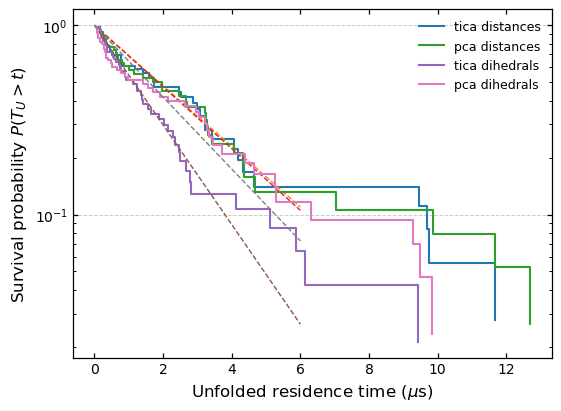

\begin{table}
\caption{Empirical unfolded-state residence times computed from the cored macrostate trajectory. $N_{\mathrm{visits}}$ is the number of unfolded visits observed in the trajectory.}
\label{tab:empirical_unfolded_residence_times}
\begin{tabular}{lrrrrrr}
\toprule
Model & $N_{\mathrm{visits}}$ & Mean waiting time [$\mu$s] & Median waiting time [$\mu$s] & P(S_0) & P(S_1) & $\Delta$ G \\
\midrule
tica\_distances & 35 & 2.712 & 1.725 & 0.311 & 0.689 & -0.471 \\
pca\_distances & 37 & 2.665 & 1.703 & 0.323 & 0.677 & -0.438 \\
tica\_dihedrals & 46 & 1.650 & 1.014 & 0.249 & 0.751 & -0.655 \\
pca\_dihedrals & 42 & 2.287 & 1.192 & 0.315 & 0.685 & -0.461 \\
\bottomrule
\end{tabular}
\end{table}



In [14]:
unfolded_rows = []

for name in trajectories_labels:
    macro_pop = macro_populations(cored_assignments_timeseries_dict[name]) # 0, 1
    times_U = np.asarray(residence_times_unfolded_dict[name], dtype=float)

    unfolded_rows.append({
        "Model": name.replace("_", r"\_"),
        r"$N_{\mathrm{visits}}$": len(times_U),
        r"Mean waiting time [$\mu$s]": times_U.mean(),
        r"Median waiting time [$\mu$s]": np.median(times_U),
        r"P(S_0)": macro_pop[0],
        r"P(S_1)": macro_pop[1],
        r"$\Delta$ G": -np.log(macro_pop[1] / macro_pop[0]) * 0.593,  # kcal/mol
    })

unfolded_waiting_df = pd.DataFrame(unfolded_rows)



fig, ax = plt.subplots(figsize=(5.5, 4), constrained_layout=True)

for name in trajectories_labels:
    times = np.asarray(residence_times_unfolded_dict[name], dtype=float)
    times = np.sort(times)

    # Empirical survival probability P(T > t)
    survival = 1.0 - np.arange(1, len(times) + 1) / (len(times) + 1)

    ax.step(
        times,
        survival,
        where="post",
        linewidth=1.5,
        label=name.replace("_", " ")
    )

    # Exponential estimate using the sample mean
    mean_time = times.mean()
    t_fit = np.linspace(0, 6, 300)

    ax.plot(
        t_fit,
        np.exp(-t_fit / mean_time),
        linestyle="--",
        linewidth=1.0
    )

ax.set_yscale("log")
ax.set_xlabel(r"Unfolded residence time ($\mu$s)")
ax.set_ylabel(r"Survival probability $P(T_U > t)$")

ax.grid(which = "major", axis = "y", linestyle = "--", linewidth = 0.7, color = "0.75", alpha = 0.8, zorder = 0)
ax.legend(frameon=False)


plt.savefig(
    "../output_figures/unfolded_residence_times_survival.pdf",
    bbox_inches="tight"
)
plt.show()




latex_table = unfolded_waiting_df.to_latex(
    index=False,
    escape=False,
    float_format="%.3f",
    caption=(
        r"Empirical unfolded-state residence times computed from the cored "
        r"macrostate trajectory. $N_{\mathrm{visits}}$ is the number of "
        r"unfolded visits observed in the trajectory."
    ),
    label="tab:empirical_unfolded_residence_times"
)

print(latex_table)

---

# PCCA++ Fuzzy populations and times

Fuzzy equilibrium populations

$
P(frame \in A) = \sum_{\text{micro}} p(frame \in \text{micro}) \cdot p(\text{micro} \in A)
$

In [17]:
import numpy as np
import pandas as pd

state_populations = {}
times = {}

# Convert MSM lag time from ns to µs
lagtime_us = MSM_LAG_NS * 1e-3

rows = {}

for name in trajectories_labels:
    pcca = pcca_dict[name]

    pops = np.asarray(
        pcca.coarse_grained_stationary_probability,
        dtype=float
    )

    T_macro = np.asarray(
        pcca.coarse_grained_transition_matrix,
        dtype=float
    )

    # Safety checks
    if len(pops) != 2:
        raise ValueError(
            f"{name}: expected 2 macrostates, got {len(pops)}"
        )

    if T_macro.shape != (2, 2):
        raise ValueError(
            f"{name}: expected a 2 × 2 transition matrix, "
            f"got {T_macro.shape}"
        )

    T_00 = T_macro[0, 0]
    T_11 = T_macro[1, 1]

    # Mean discrete-state waiting time:
    # <t_i> = lagtime / (1 - T_ii)
    t_0 = lagtime_us / (1.0 - T_00)
    t_1 = lagtime_us / (1.0 - T_11)

    state_populations[name] = pops
    times[name] = {
        "t_0": t_0,
        "t_1": t_1,
    }

    rows[name] = {
        "$P(S_0)$": pops[0],
        "$P(S_1)$": pops[1],
        "$t_0$ ($\\mu$s)": t_0,
        "$t_1$ ($\\mu$s)": t_1,
    }


# ------------------------------------------------------------
# Build DataFrame
# ------------------------------------------------------------
population_df = pd.DataFrame.from_dict(
    rows,
    orient="index"
)

population_df.index.name = "Model"


# ------------------------------------------------------------
# Relative free energy
# ------------------------------------------------------------
T = 360  # K
kB = 0.0019872043  # kcal mol^-1 K^-1
kBT = kB * T

population_df[
    "$\\Delta G_{1-0}$ (kcal mol$^{-1}$)"
] = (
    -kBT
    * np.log(
        population_df["$P(S_1)$"]
        / population_df["$P(S_0)$"]
    )
)


# ------------------------------------------------------------
# Export to LaTeX
# ------------------------------------------------------------
latex_df = population_df.reset_index()

latex_table = latex_df.to_latex(
    index=False,
    float_format="%.3f",
    escape=False,
    caption=(
        "Coarse-grained stationary populations and mean waiting times "
        "of the two PCCA macrostates for each MSM at the common "
        "two-state resolution. Mean waiting times were calculated as "
        "$\\langle t_i \\rangle = \\tau/(1-T_{ii})$, where $\\tau$ is "
        "the MSM lag time. Relative free energies were computed as "
        "$\\Delta G_{1-0} = -k_B T \\ln[P(S_1)/P(S_0)]$ "
        f"with $T={T}$ K."
    ),
    label="tab:pcca_two_state_populations",
    column_format="lccccc"
)

print(population_df)
print()
print(latex_table)

                $P(S_0)$  $P(S_1)$  $t_0$ ($\mu$s)  $t_1$ ($\mu$s)  \
Model                                                                
tica_distances  0.230439  0.769561        1.590673        5.312136   
pca_distances   0.302958  0.697042        1.932557        4.446414   
tica_dihedrals  0.217671  0.782329        1.470738        5.285959   
pca_dihedrals   0.358309  0.641691        1.407369        2.520435   

                $\Delta G_{1-0}$ (kcal mol$^{-1}$)  
Model                                               
tica_distances                           -0.862648  
pca_distances                            -0.596104  
tica_dihedrals                           -0.915196  
pca_dihedrals                            -0.416867  

\begin{table}
\caption{Coarse-grained stationary populations and mean waiting times of the two PCCA macrostates for each MSM at the common two-state resolution. Mean waiting times were calculated as $\langle t_i \rangle = \tau/(1-T_{ii})$, where $\tau$ is the 